In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Indian Population Dataset.xlsx to Indian Population Dataset.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel(next(iter(uploaded)))

In [ ]:
df.head()

,State,Region,Population,Area_km2,Literacy_Rate,Density
0,Karnataka,South,67562686,191791,75.86,834
1,Tamil Nadu,South,72147030,130058,24.56,349
2,Kerala,South,35699443,38863,21.66,245
3,Maharashtra,West,124904071,307713,90.97,653
4,Delhi,North,16787941,1484,78.09,765


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State          10 non-null     object 
 1   Region         10 non-null     object 
 2   Population     10 non-null     int64  
 3   Area_km2       10 non-null     int64  
 4   Literacy_Rate  10 non-null     float64
 5   Density        10 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 612.0+ bytes


In [ ]:
df.isnull().sum()

,0
State,0
Region,0
Population,0
Area_km2,0
Literacy_Rate,0
Density,0


In [ ]:
df.columns

Index(['State', 'Region', 'Population', 'Area_km2', 'Literacy_Rate',
       'Density'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["State_Label"] = le.fit_transform(df["State"])
df["Region_Label"] = le.fit_transform(df["Region"])

df[["State", "State_Label", "Region", "Region_Label"]].head()

,State,State_Label,Region,Region_Label
0,Karnataka,3,South,2
1,Tamil Nadu,7,South,2
2,Kerala,4,South,2
3,Maharashtra,5,West,3
4,Delhi,1,North,1


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[["Region"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["Region"])
)

df = pd.concat([df, encoded_df], axis=1)

df.head()

,State,Region,Population,Area_km2,Literacy_Rate,Density,State_Label,Region_Label,Region_East,Region_North,Region_South,Region_West
0,Karnataka,South,67562686,191791,75.86,834,3,2,0.0,0.0,1.0,0.0
1,Tamil Nadu,South,72147030,130058,24.56,349,7,2,0.0,0.0,1.0,0.0
2,Kerala,South,35699443,38863,21.66,245,4,2,0.0,0.0,1.0,0.0
3,Maharashtra,West,124904071,307713,90.97,653,5,3,0.0,0.0,0.0,1.0
4,Delhi,North,16787941,1484,78.09,765,1,1,0.0,1.0,0.0,0.0


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Create a sample ordinal column
levels = ["Low", "Medium", "High"]

df["Population_Level"] = [levels[i % 3] for i in range(len(df))]

# Apply OrdinalEncoder
oe = OrdinalEncoder(categories=[["Low", "Medium", "High"]])

df["Population_Level_Encoded"] = oe.fit_transform(df[["Population_Level"]])

# Display the result
df[["Population_Level", "Population_Level_Encoded"]].head(10)

,Population_Level,Population_Level_Encoded
0,Low,0.0
1,Medium,1.0
2,High,2.0
3,Low,0.0
4,Medium,1.0
5,High,2.0
6,Low,0.0
7,Medium,1.0
8,High,2.0
9,Low,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Numerical columns
numeric_cols = ["Population", "Area_km2", "Literacy_Rate", "Density"]

# Create scaler objects
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

# Apply StandardScaler
df_standard = df.copy()
df_standard[numeric_cols] = standard_scaler.fit_transform(df_standard[numeric_cols])

# Apply MinMaxScaler
df_minmax = df.copy()
df_minmax[numeric_cols] = minmax_scaler.fit_transform(df_minmax[numeric_cols])

# Apply RobustScaler
df_robust = df.copy()
df_robust[numeric_cols] = robust_scaler.fit_transform(df_robust[numeric_cols])

print("Scaling completed successfully!")

Scaling completed successfully!


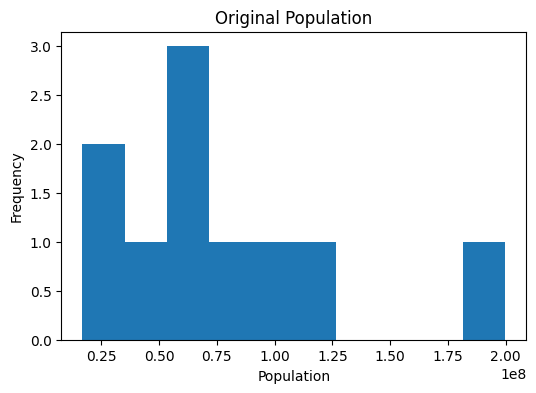

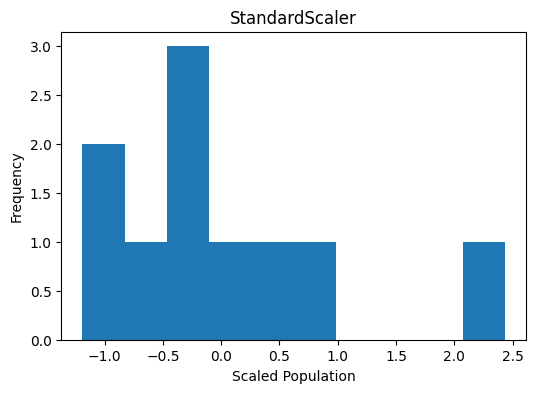

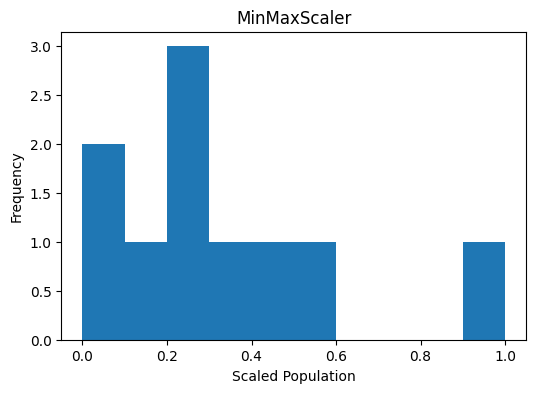

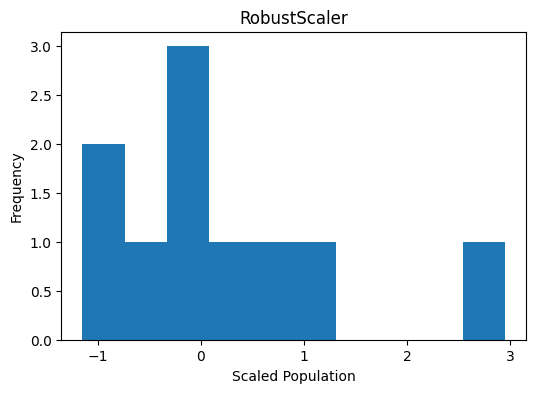

In [ ]:
import matplotlib.pyplot as plt

# Original Population
plt.figure(figsize=(6,4))
plt.hist(df["Population"], bins=10)
plt.title("Original Population")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show()

# StandardScaler
plt.figure(figsize=(6,4))
plt.hist(df_standard["Population"], bins=10)
plt.title("StandardScaler")
plt.xlabel("Scaled Population")
plt.ylabel("Frequency")
plt.show()

# MinMaxScaler
plt.figure(figsize=(6,4))
plt.hist(df_minmax["Population"], bins=10)
plt.title("MinMaxScaler")
plt.xlabel("Scaled Population")
plt.ylabel("Frequency")
plt.show()

# RobustScaler
plt.figure(figsize=(6,4))
plt.hist(df_robust["Population"], bins=10)
plt.title("RobustScaler")
plt.xlabel("Scaled Population")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

# Select only numerical columns
numeric_df = df.select_dtypes(include=["number"])

# Features (X)
X = numeric_df.drop(columns=["Population"])

# Target (y)
y = numeric_df["Population"]

# Select top 5 features
selector = SelectKBest(score_func=f_regression, k=5)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Top 5 Features:")
print(selected_features)

Top 5 Features:
Index(['Area_km2', 'Literacy_Rate', 'Density', 'State_Label', 'Region_South'], dtype='object')


Top Features Identified using SelectKBest

1. Area_km2 – Helps explain the geographical size of each state.
2. Density – Indicates population concentration.
3. Literacy_Rate – Represents the educational level of the population.
4. State_Label – Encodes state information for machine learning.
5. Region_Label – Encodes regional information useful for prediction.

These features were selected because they show the strongest statistical relationship with the target variable (Population).